# ARTI404 - Image Processing
## Lab 3: Image Manipulations using OpenCV Library



### Step 0: Install packages and download the sample image (run once)

In [1]:
%pip install -q opencv-python numpy matplotlib

import os

images_dir = os.path.join(os.getcwd(), 'images')
os.makedirs(images_dir, exist_ok=True)

url = 'https://raw.githubusercontent.com/PacktPublishing/OpenCV-3-x-with-Python-By-Example/master/Chapter01/images/input.jpg'
dest = os.path.join(images_dir, 'input.jpg')

!curl -L -s -o "{dest}" "{url}"
size = os.path.getsize(dest) if os.path.exists(dest) else 0
print(f'input.jpg: {"OK" if size > 0 else "FAILED"} ({size} bytes) -> {dest}')

Note: you may need to restart the kernel to use updated packages.
input.jpg: OK (127967 bytes) -> c:\Users\dania\Image_Processing_Labs\Lab3\images\input.jpg


### Step#1: Read an image using the OpenCV library

<class 'numpy.ndarray'>
shape: (458, 812, 3)


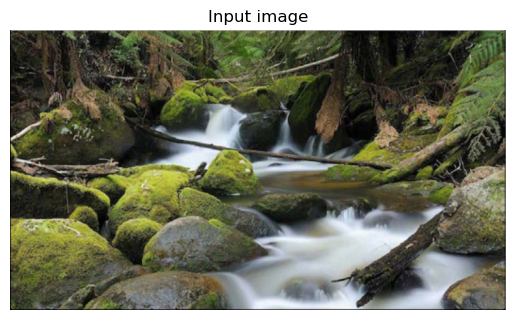

In [2]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(os.path.join('images', 'input.jpg'))

print(type(img))
print('shape:', img.shape)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Input image')
plt.axis('off')
plt.show()

### Step#2: Load an image in grayscale mode

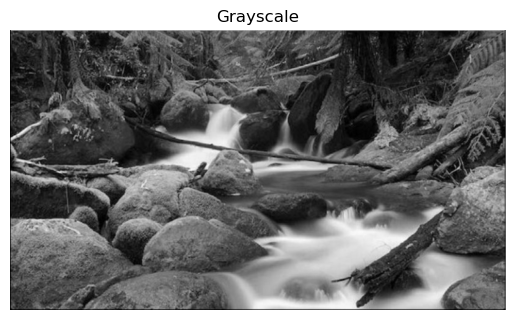

In [3]:
gray_img = cv2.imread(os.path.join('images', 'input.jpg'), cv2.IMREAD_GRAYSCALE)

plt.imshow(gray_img, cmap='gray')
plt.title('Grayscale')
plt.axis('off')
plt.show()

### Step#3: Save an image

In [4]:
os.makedirs('output', exist_ok=True)
cv2.imwrite(os.path.join('output', 'output.jpg'), gray_img)
print('Saved output/output.jpg')

Saved output/output.jpg


### Step#4: Convert an image to different color spaces

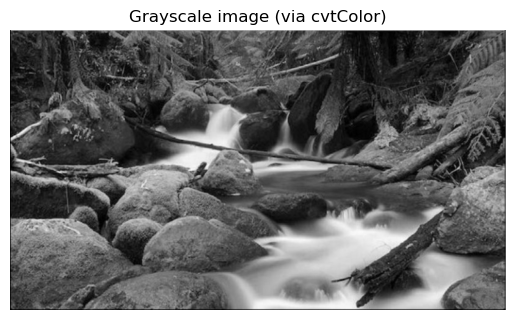

In [5]:
img = cv2.imread(os.path.join('images', 'input.jpg'))
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray_img, cmap='gray')
plt.title('Grayscale image (via cvtColor)')
plt.axis('off')
plt.show()

Considering all the color spaces, there are around 190 conversion options available in OpenCV. The following prints the full list of color-related flags:

In [6]:
print([x for x in dir(cv2) if x.startswith('COLOR_')])

['COLOR_BAYER_BG2BGR', 'COLOR_BAYER_BG2BGRA', 'COLOR_BAYER_BG2BGR_EA', 'COLOR_BAYER_BG2BGR_VNG', 'COLOR_BAYER_BG2GRAY', 'COLOR_BAYER_BG2RGB', 'COLOR_BAYER_BG2RGBA', 'COLOR_BAYER_BG2RGB_EA', 'COLOR_BAYER_BG2RGB_VNG', 'COLOR_BAYER_BGGR2BGR', 'COLOR_BAYER_BGGR2BGRA', 'COLOR_BAYER_BGGR2BGR_EA', 'COLOR_BAYER_BGGR2BGR_VNG', 'COLOR_BAYER_BGGR2GRAY', 'COLOR_BAYER_BGGR2RGB', 'COLOR_BAYER_BGGR2RGBA', 'COLOR_BAYER_BGGR2RGB_EA', 'COLOR_BAYER_BGGR2RGB_VNG', 'COLOR_BAYER_GB2BGR', 'COLOR_BAYER_GB2BGRA', 'COLOR_BAYER_GB2BGR_EA', 'COLOR_BAYER_GB2BGR_VNG', 'COLOR_BAYER_GB2GRAY', 'COLOR_BAYER_GB2RGB', 'COLOR_BAYER_GB2RGBA', 'COLOR_BAYER_GB2RGB_EA', 'COLOR_BAYER_GB2RGB_VNG', 'COLOR_BAYER_GBRG2BGR', 'COLOR_BAYER_GBRG2BGRA', 'COLOR_BAYER_GBRG2BGR_EA', 'COLOR_BAYER_GBRG2BGR_VNG', 'COLOR_BAYER_GBRG2GRAY', 'COLOR_BAYER_GBRG2RGB', 'COLOR_BAYER_GBRG2RGBA', 'COLOR_BAYER_GBRG2RGB_EA', 'COLOR_BAYER_GBRG2RGB_VNG', 'COLOR_BAYER_GR2BGR', 'COLOR_BAYER_GR2BGRA', 'COLOR_BAYER_GR2BGR_EA', 'COLOR_BAYER_GR2BGR_VNG', 'COLOR_

Convert to YUV (Y: brightness, U: blue projection, V: red projection) and view each channel separately:

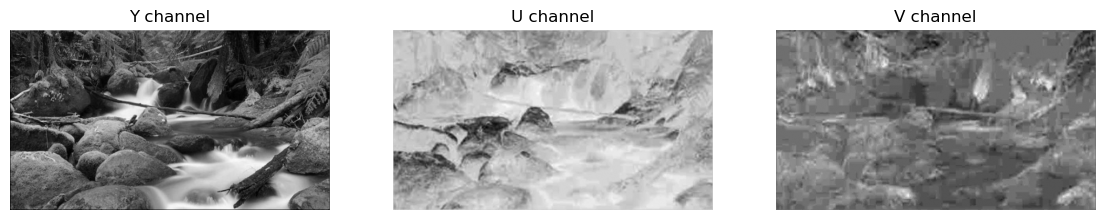

In [7]:
yuv_img = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(yuv_img[:, :, 0], cmap='gray'); axes[0].set_title('Y channel'); axes[0].axis('off')
axes[1].imshow(yuv_img[:, :, 1], cmap='gray'); axes[1].set_title('U channel'); axes[1].axis('off')
axes[2].imshow(yuv_img[:, :, 2], cmap='gray'); axes[2].set_title('V channel'); axes[2].axis('off')
plt.show()

## Assessment

### Task#1: Geometric transformations
1. Increase the size of the image.
2. Rotate the image by 120 degrees.
3. Perform a shear operation over the image.

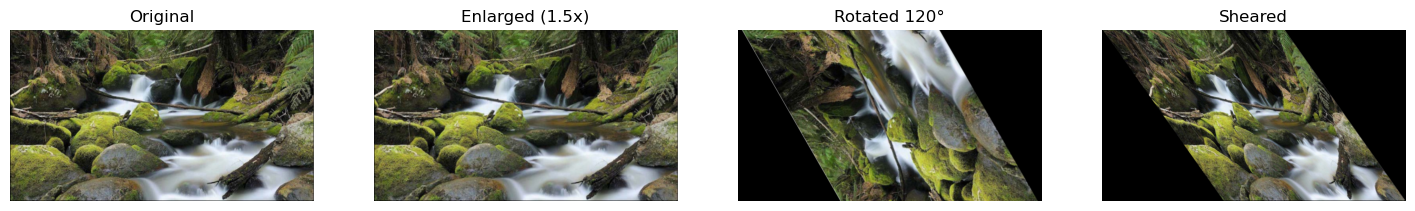

In [8]:
import numpy as np

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
rows, cols = img_rgb.shape[:2]

# 1. Increase the size of the image (scale up by 1.5x)
enlarged = cv2.resize(img_rgb, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_LINEAR)

# 2. Rotate the image by 120 degrees
rotation_matrix = cv2.getRotationMatrix2D((cols / 2, rows / 2), 120, 1)
rotated = cv2.warpAffine(img_rgb, rotation_matrix, (cols, rows))

# 3. Shear operation (affine transform that skews the image)
src_points = np.float32([[0, 0], [cols - 1, 0], [0, rows - 1]])
dst_points = np.float32([[0, 0], [int(0.6 * (cols - 1)), 0], [int(0.4 * (cols - 1)), rows - 1]])
shear_matrix = cv2.getAffineTransform(src_points, dst_points)
sheared = cv2.warpAffine(img_rgb, shear_matrix, (cols, rows))

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(img_rgb); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(enlarged); axes[1].set_title('Enlarged (1.5x)'); axes[1].axis('off')
axes[2].imshow(rotated); axes[2].set_title('Rotated 120°'); axes[2].axis('off')
axes[3].imshow(sheared); axes[3].set_title('Sheared'); axes[3].axis('off')
plt.show()

### Task#2: Intensity transformations
1. Create a negative image.
2. Log transform (choose an appropriate constant for your image).
3. Power law / gamma transform (choose a gamma that increases the contrast).

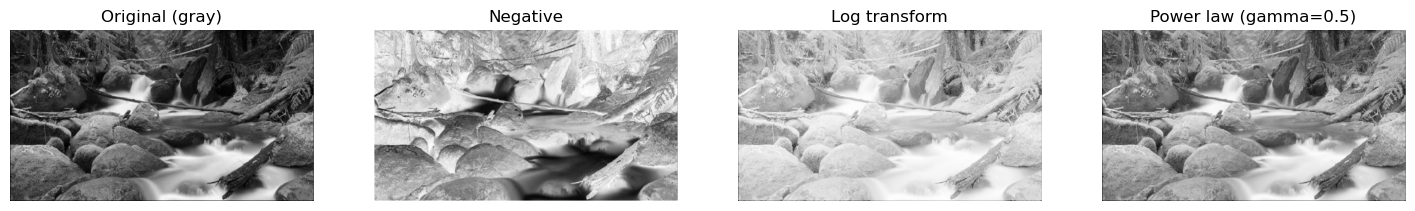

In [9]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)

# 1. Negative image
negative = 255 - gray

# 2. Log transform: s = c * log(1 + r)
c_log = 255 / np.log(1 + 255)
log_transformed = c_log * np.log(1 + gray)
log_transformed = np.clip(log_transformed, 0, 255).astype(np.uint8)

# 3. Power law (gamma) transform: s = c * r^gamma
gamma = 0.5  # gamma < 1 increases contrast/brightens the image
normalized = gray / 255.0
power_law = np.clip((normalized ** gamma) * 255, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(gray.astype(np.uint8), cmap='gray'); axes[0].set_title('Original (gray)'); axes[0].axis('off')
axes[1].imshow(negative.astype(np.uint8), cmap='gray'); axes[1].set_title('Negative'); axes[1].axis('off')
axes[2].imshow(log_transformed, cmap='gray'); axes[2].set_title('Log transform'); axes[2].axis('off')
axes[3].imshow(power_law, cmap='gray'); axes[3].set_title(f'Power law (gamma={gamma})'); axes[3].axis('off')
plt.show()